<a href="https://colab.research.google.com/github/Leorasaharia/preseizure-instability-eeg/blob/main/eeg_neural_instability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb mne numpy scipy pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import wfdb
import os

db_name = "chbmit"
dl_dir = "chbmit_data"

# Ensure the download directory exists
os.makedirs(dl_dir, exist_ok=True)

print(f"Downloading all .edf files from '{db_name}' database to '{dl_dir}'...")

try:
    # Download all .edf files for all records in the database
    wfdb.dl_database(db_name,
                     dl_dir=dl_dir,
                     files=['.edf'], # Only download .edf files
                     overwrite=False) # Set to True if you want to re-download existing files
    print("Download process complete.")
except Exception as e:
    print(f"An error occurred during download: {e}")

An error occurred during download: dl_database() got an unexpected keyword argument 'files'


In [ ]:
!rm -rf chbmit_data
!mkdir chbmit_data


In [ ]:
!wget -r -np -nH --cut-dirs=3 -A "*.edf" \
https://physionet.org/files/chbmit/1.0.0/chb01/ \
-P chbmit_data


--2026-01-20 13:21:03--  https://physionet.org/files/chbmit/1.0.0/chb01/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘chbmit_data/chb01/index.html.tmp’

chb01/index.html.tm     [ <=>                ]   6.00K  --.-KB/s    in 0s      

2026-01-20 13:21:04 (712 MB/s) - ‘chbmit_data/chb01/index.html.tmp’ saved [6149]

Loading robots.txt; please ignore errors.
--2026-01-20 13:21:04--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 22 [text/plain]
Saving to: ‘chbmit_data/robots.txt.tmp’

robots.txt.tmp      100%[===================>]      22  --.-KB/s    in 0s      

2026-01-20 13:21:04 (4.67 MB/s) - ‘chbmit_data/robots.txt.tmp’ saved [22/22]

Removing chbmit_data/robots.txt.tmp.
Removing chbmit_data/chb01/index.html.tmp since it

In [ ]:
!ls chbmit_data/chb01


chb01_01.edf  chb01_10.edf  chb01_19.edf  chb01_29.edf	chb01_39.edf
chb01_02.edf  chb01_11.edf  chb01_20.edf  chb01_30.edf	chb01_40.edf
chb01_03.edf  chb01_12.edf  chb01_21.edf  chb01_31.edf	chb01_41.edf
chb01_04.edf  chb01_13.edf  chb01_22.edf  chb01_32.edf	chb01_42.edf
chb01_05.edf  chb01_14.edf  chb01_23.edf  chb01_33.edf	chb01_43.edf
chb01_06.edf  chb01_15.edf  chb01_24.edf  chb01_34.edf	chb01_46.edf
chb01_07.edf  chb01_16.edf  chb01_25.edf  chb01_36.edf
chb01_08.edf  chb01_17.edf  chb01_26.edf  chb01_37.edf
chb01_09.edf  chb01_18.edf  chb01_27.edf  chb01_38.edf


In [ ]:
import os
import mne
import numpy as np

In [ ]:
patient_dir = "chbmit_data/chb01"

seizure_files = []

for file in sorted(os.listdir(patient_dir)):
    if file.endswith(".edf"):
        edf_path = os.path.join(patient_dir, file)

        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

        seizures = []
        for desc, onset, duration in zip(
            raw.annotations.description,
            raw.annotations.onset,
            raw.annotations.duration
        ):
            if "seizure" in desc.lower():
                seizures.append((onset, onset + duration))

        if len(seizures) > 0:
            seizure_files.append((file, seizures))
            print(f"\n🟢 Seizure found in {file}")
            print("   Seizure intervals (sec):", seizures)
        else:
            print(f"⚪ No seizure in {file}")

/tmp/ipython-input-4228500782.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


⚪ No seizure in chb01_01.edf


/tmp/ipython-input-4228500782.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


⚪ No seizure in chb01_02.edf


/tmp/ipython-input-4228500782.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


...

⚪ No seizure in chb01_42.edf


/tmp/ipython-input-4228500782.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


⚪ No seizure in chb01_43.edf


/tmp/ipython-input-4228500782.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


⚪ No seizure in chb01_46.edf


Using matplotlib as 2D backend.


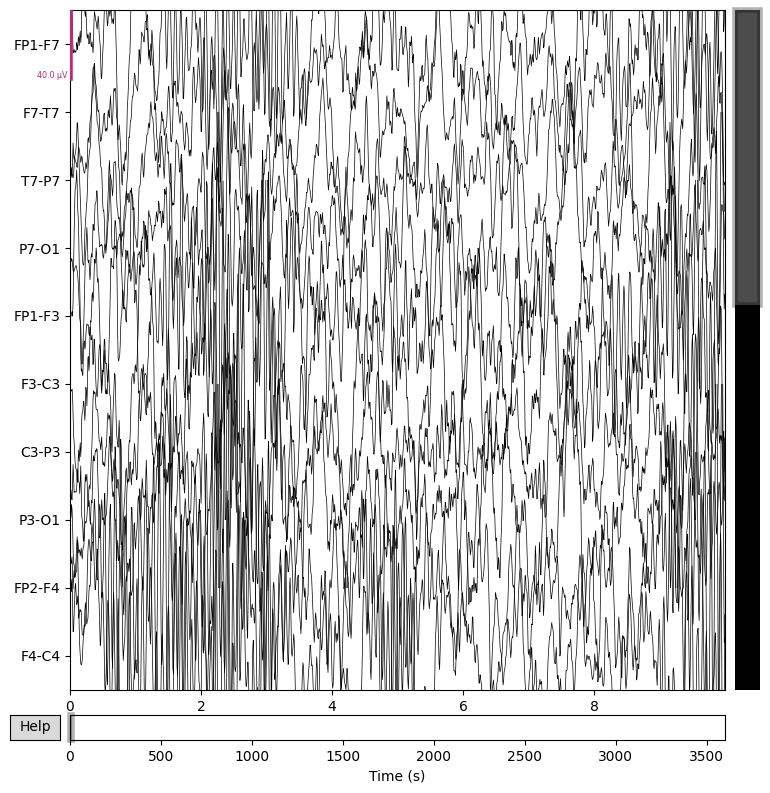

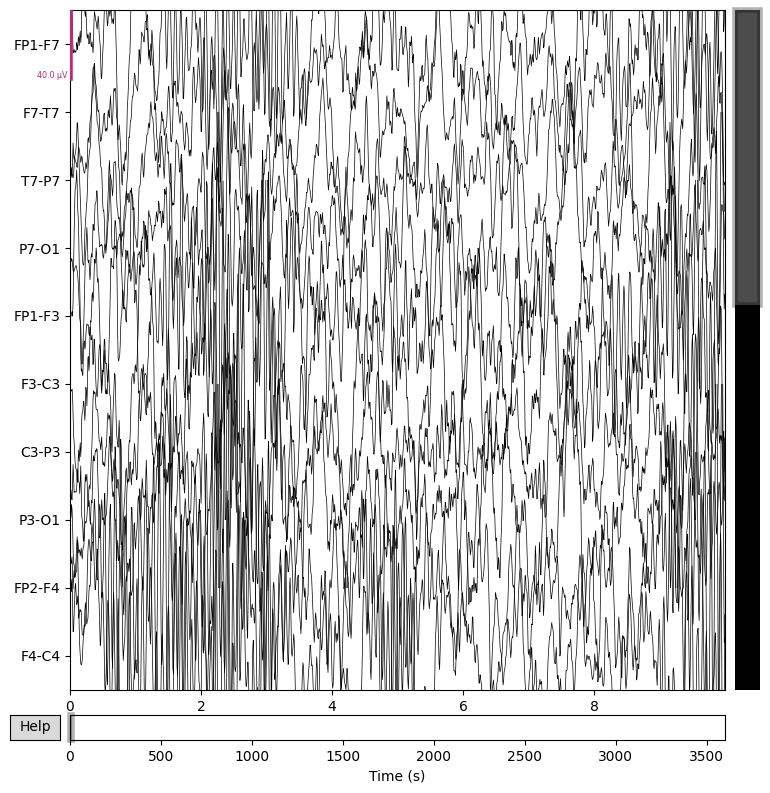

In [ ]:
raw.plot(n_channels=10, duration=10)


In [ ]:
import mne

edf_path = "chbmit_data/chb01/chb01_03.edf"

raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
raw.filter(1, 40)

/tmp/ipython-input-2298524506.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)



<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [ ]:
from google.colab import files
files.upload()

Saving chb01_26.edf.seizures to chb01_26.edf.seizures
Saving chb01_21.edf.seizures to chb01_21.edf.seizures
Saving chb01_15.edf.seizures to chb01_15.edf.seizures
Saving chb01_04.edf.seizures to chb01_04.edf.seizures
Saving chb01_03.edf.seizures to chb01_03.edf.seizures


{'chb01_26.edf.seizures': b'\x00X\x17\xfc## time resolution: 256\x00\x00\xec\xff\xff\xff\xff\x01\x00\x00\xec\x07\x00\x00F\x00\x80\x00\xec\x00\x00\x00e\x00\x84\x00\x00',
 'chb01_21.edf.seizures': b'\x00X\x17\xfc## time resolution: 256\x00\x00\xec\xff\xff\xff\xff\x01\x00\x00\xec\x01\x00\x00G\x00\x80\x00\xec\x00\x00\x00]\x00\x84\x00\x00',
 'chb01_15.edf.seizures': b'\x00X\x17\xfc## time resolution: 256\x00\x00\xec\xff\xff\xff\xff\x01\x00\x00\xec\x06\x00\x00\xc4\x00\x80\x00\xec\x00\x00\x00(\x00\x84\x00\x00',
 'chb01_04.edf.seizures': b'\x00X\x17\xfc## time resolution: 256\x00\x00\xec\xff\xff\xff\xff\x01\x00\x00\xec\x05\x00\x00\xbb\x00\x80\x00\xec\x00\x00\x00\x1b\x00\x84\x00\x00',
 'chb01_03.edf.seizures': b'\x00X\x17\xfc## time resolution: 256\x00\x00\xec\xff\xff\xff\xff\x01\x00\x00\xec\x0b\x00\x00\xb4\x00\x80\x00\xec\x00\x00\x00(\x00\x84\x00\x00'}

In [ ]:
!mv chb01_*.edf.seizures chbmit_data/chb01/

In [ ]:
!ls chbmit_data/chb01 | grep seizures

chb01_03.edf.seizures
chb01_04.edf.seizures
chb01_15.edf.seizures
chb01_21.edf.seizures
chb01_26.edf.seizures


In [ ]:
import mne

edf_path = "chbmit_data/chb01/chb01_03.edf"

raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=True)
raw.filter(1, 40)

print(raw.annotations)

Extracting EDF parameters from chbmit_data/chb01/chb01_03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipython-input-3334131858.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)

<Annotations | 0 segments>


In [56]:
import wfdb
import os

record_name_only = "chb01_03"
record_dir = "chbmit_data/chb01"
full_record_path = os.path.join(record_dir, record_name_only)

ann = wfdb.rdann(
    full_record_path,
    extension="edf.seizures"
)

print("Annotation sample indices:", ann.sample)
print("Annotation labels:", ann.symbol)

Annotation sample indices: [766976 777216]
Annotation labels: ['[', ']']


In [57]:
import numpy as np

sfreq = raw.info["sfreq"]  # 256 Hz

seizure_onsets = ann.sample / sfreq

print("Seizure onset times (sec):", seizure_onsets)


Seizure onset times (sec): [2996. 3036.]


In [58]:
# CHB-MIT uses start/end pairs
seizure_intervals = []

for i in range(0, len(seizure_onsets), 2):
    start = seizure_onsets[i]
    end = seizure_onsets[i+1]
    seizure_intervals.append((start, end))

print("Seizure intervals:", seizure_intervals)

Seizure intervals: [(np.float64(2996.0), np.float64(3036.0))]


In [59]:
onsets = [s[0] for s in seizure_intervals]
durations = [s[1] - s[0] for s in seizure_intervals]
descriptions = ["Seizure"] * len(seizure_intervals)

raw.set_annotations(
    mne.Annotations(onsets, durations, descriptions)
)

print(raw.annotations)

<Annotations | 1 segment: Seizure (1)>


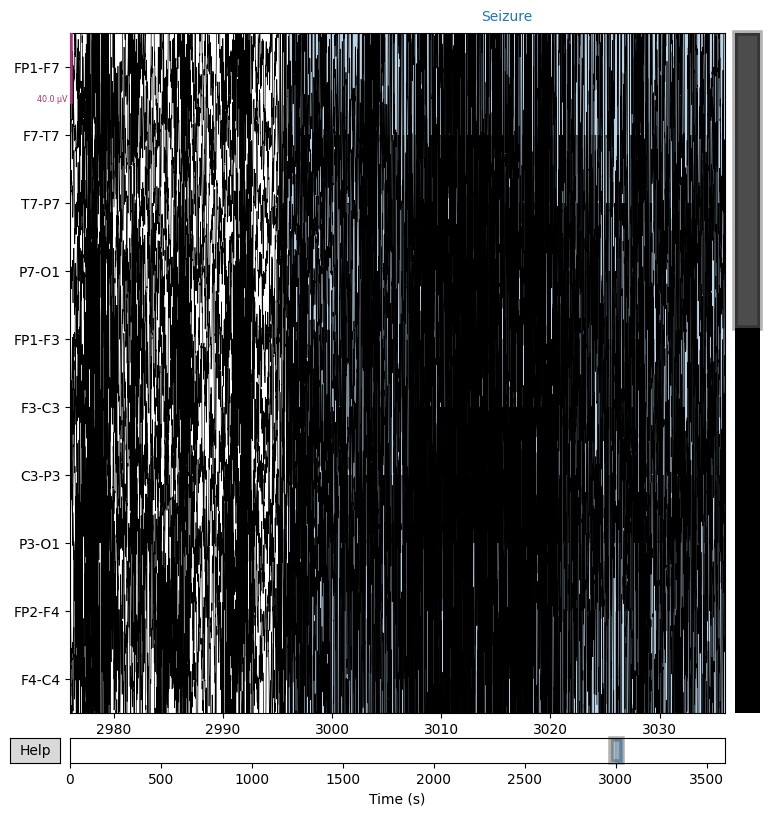

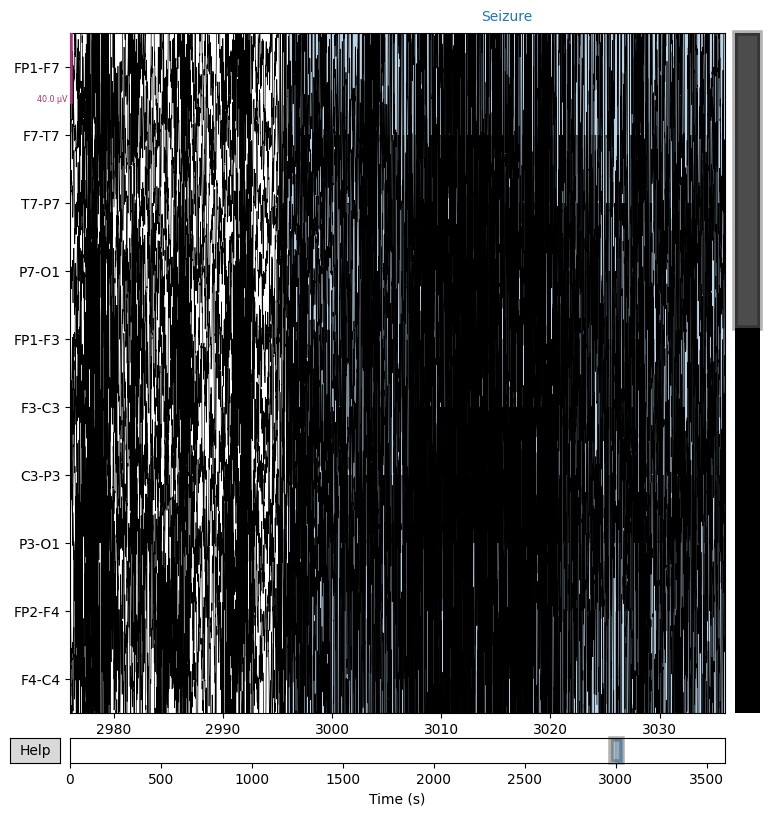

In [60]:
raw.plot(
    start=seizure_intervals[0][0] - 20,
    duration=60,
    n_channels=10
)

In [62]:
import numpy as np

def early_warning_metrics(epoch):
    metrics = []
    for ch in epoch:
        var = np.var(ch)
        ac = np.corrcoef(ch[:-1], ch[1:])[0,1]
        diff = np.mean(np.abs(np.diff(ch)))
        metrics.extend([var, ac, diff])
    return metrics

In [63]:
pre_seizure_raw = raw.copy().crop(
    tmin=max(0, seizure_intervals[0][0] - 30*60),
    tmax=seizure_intervals[0][0]
)

baseline_raw = raw.copy().crop(tmin=0, tmax=30*60)

In [64]:
pre_epochs = mne.make_fixed_length_epochs(
    pre_seizure_raw, duration=10, overlap=8
)

base_epochs = mne.make_fixed_length_epochs(
    baseline_raw, duration=10, overlap=8
)

Not setting metadata
896 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
896 matching events found
No baseline correction applied
0 projection items activated


In [65]:
X_pre = np.array([early_warning_metrics(ep) for ep in pre_epochs])
X_base = np.array([early_warning_metrics(ep) for ep in base_epochs])

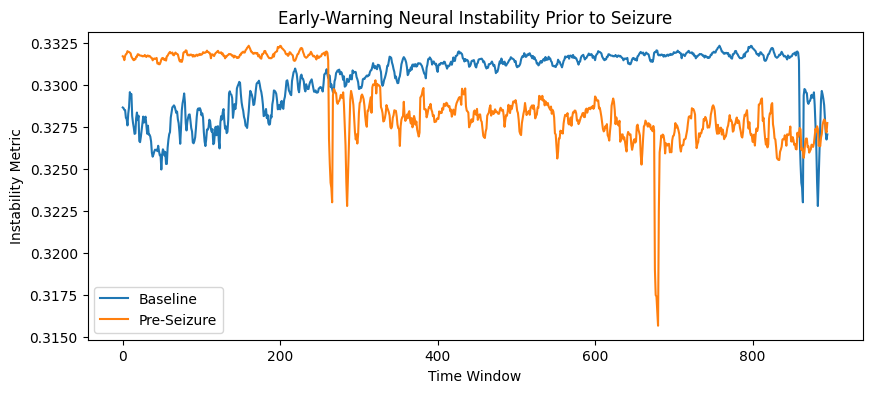

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(np.mean(X_base, axis=1), label="Baseline")
plt.plot(np.mean(X_pre, axis=1), label="Pre-Seizure")
plt.legend()
plt.xlabel("Time Window")
plt.ylabel("Instability Metric")
plt.title("Early-Warning Neural Instability Prior to Seizure")
plt.show()

In [67]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    X_pre.mean(axis=1),
    X_base.mean(axis=1),
    equal_var=False
)

print("p-value:", p_val)


p-value: 1.3369598161236512e-53


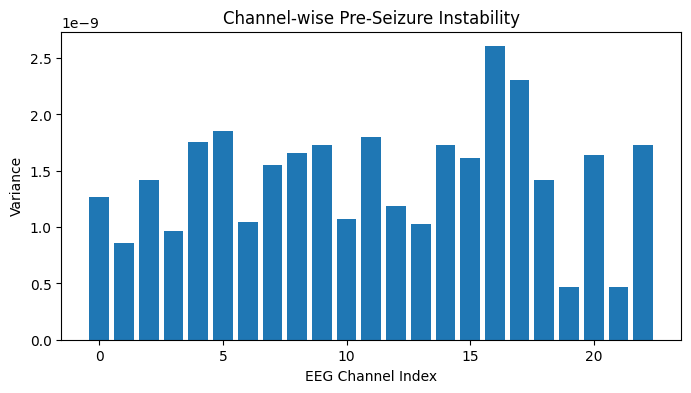

In [68]:
channel_variance = np.mean(
    [np.var(ep, axis=1) for ep in pre_epochs],
    axis=0
)

plt.figure(figsize=(8,4))
plt.bar(range(len(channel_variance)), channel_variance)
plt.xlabel("EEG Channel Index")
plt.ylabel("Variance")
plt.title("Channel-wise Pre-Seizure Instability")
plt.show()

In [69]:
from sklearn.ensemble import RandomForestClassifier

X = np.vstack([X_base, X_pre])
y = np.array([0]*len(X_base) + [1]*len(X_pre))

clf = RandomForestClassifier(n_estimators=100)
clf.fit(X, y)

print("Model trained successfully")

Model trained successfully


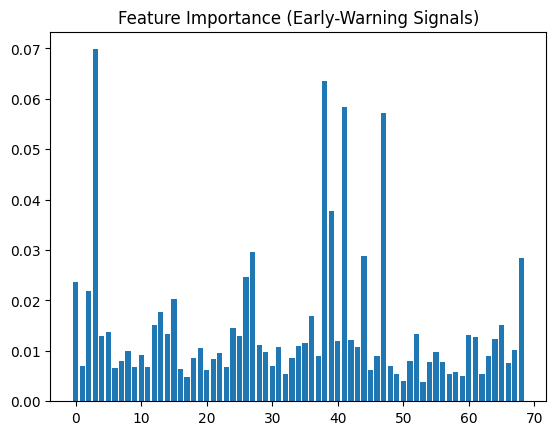

In [70]:
plt.bar(range(len(clf.feature_importances_)), clf.feature_importances_)
plt.title("Feature Importance (Early-Warning Signals)")
plt.show()